NAME : GAURI PATKI


College: PES Modern college of Engineering

**TASK 2 : UNEMPLOYMENT ANALYSIS WITH PYTHON**





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
data = pd.read_csv("/content/Unemployment in India.csv")
data = pd.read_csv("/content/Unemployment_Rate_upto_11_2020.csv")
print(data.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

In [3]:
data

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.740
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.740
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.740
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.740
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.740
...,...,...,...,...,...,...,...,...,...
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855


In [4]:
data.shape

(267, 9)

In [5]:
data.dtypes

,0
Region,object
Date,object
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,int64
Estimated Labour Participation Rate (%),float64
Region.1,object
longitude,float64
latitude,float64


In [6]:
print(data.isnull().sum())

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


In [7]:
data.columns= ["States","Date","Frequency",
               "Estimated Unemployment Rate",
               "Estimated Employed",
               "Estimated Labour Participation Rate",
               "Region","longitude","latitude"]

CORRELATION

In [8]:
plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr())
plt.show()

OSError: 'seaborn-whitegrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

DATA VISUALISATION


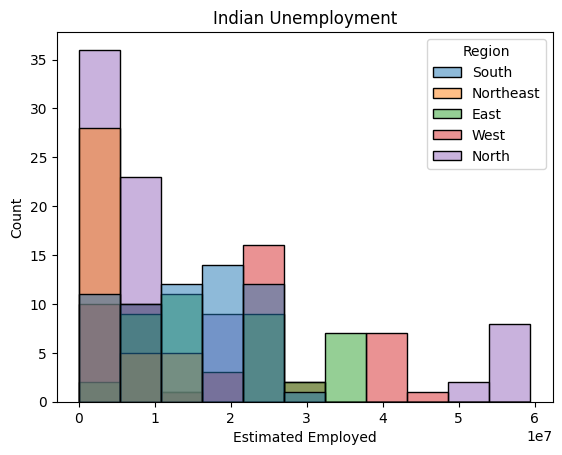

In [9]:
data.columns= ["States","Date","Frequency",
               "Estimated Unemployment Rate","Estimated Employed",
               "Estimated Labour Participation Rate","Region",
               "longitude","latitude"]
plt.title("Indian Unemployment")
sns.histplot(x="Estimated Employed", hue="Region", data=data)
plt.show()

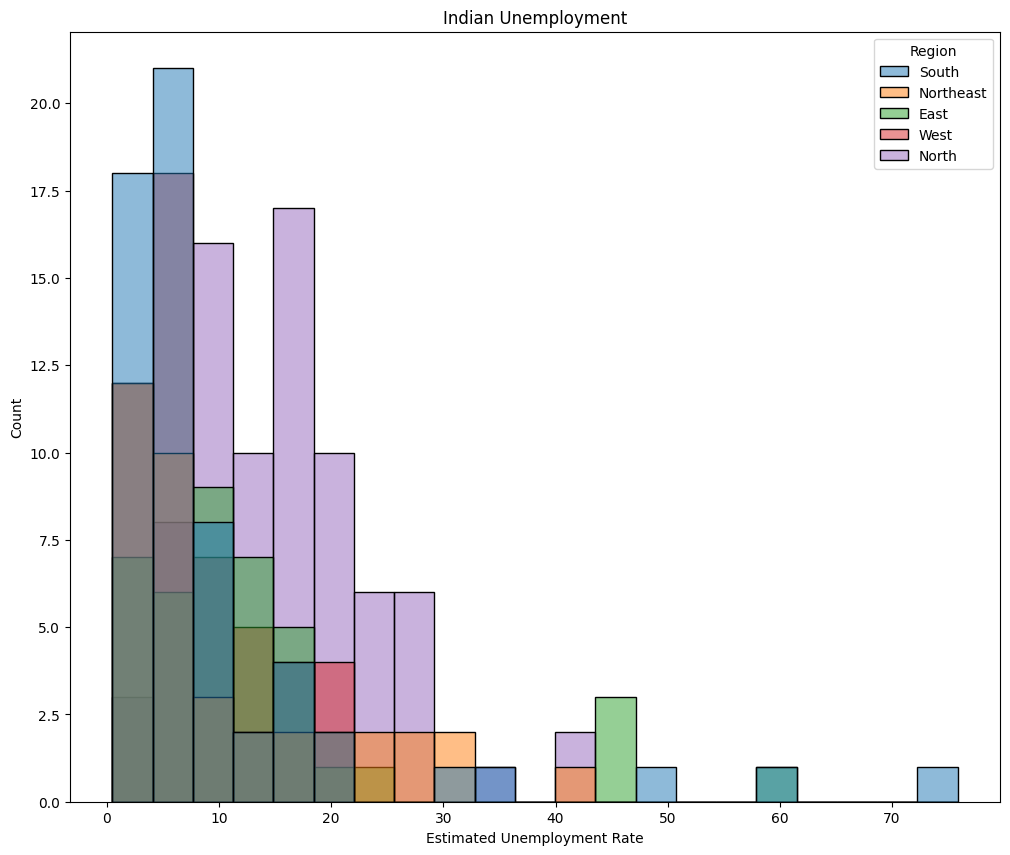

In [10]:
plt.figure(figsize=(12, 10))
plt.title("Indian Unemployment")
sns.histplot(x="Estimated Unemployment Rate", hue="Region", data=data)
plt.show()

In [11]:
unemploment = data[["States", "Region", "Estimated Unemployment Rate"]]
figure = px.sunburst(unemploment, path=["Region", "States"],
                     values="Estimated Unemployment Rate",
                     width=700, height=700, color_continuous_scale="RdY1Gn",
                     title="Unemployment Rate in India")
figure.show()

In [12]:
data["Date"] = pd.to_datetime(data["Date"], dayfirst=True)

# National trend by month
monthly = data.groupby(data["Date"].dt.month)["Estimated Unemployment Rate"].mean()
print(monthly)

# Peak vs pre-lockdown by state
pre = data[data["Date"].dt.month == 3].set_index("States")["Estimated Unemployment Rate"]
peak = data[data["Date"].dt.month == 4].set_index("States")["Estimated Unemployment Rate"]
jump = (peak - pre).sort_values(ascending=False)
print(jump.head(5))

# Region comparison
print(data.groupby("Region")["Estimated Unemployment Rate"].mean().sort_values())

# Recovery: Oct vs April
oct_ = data[data["Date"].dt.month == 10].set_index("States")["Estimated Unemployment Rate"]
print((peak - oct_).sort_values(ascending=False).head(5))

Date
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name: Estimated Unemployment Rate, dtype: float64
States
Puducherry    74.65
Tamil Nadu    43.43
Jharkhand     38.86
Bihar         31.21
Karnataka     26.38
Name: Estimated Unemployment Rate, dtype: float64
Region
West          8.239000
South        10.454667
Northeast    10.950263
East         13.916000
North        15.889620
Name: Estimated Unemployment Rate, dtype: float64
States
Puducherry    69.67
Tamil Nadu    47.67
Bihar         36.82
Jharkhand     35.29
Tripura       29.66
Name: Estimated Unemployment Rate, dtype: float64


In [13]:
# States still worse off in Oct than pre-lockdown
still_high = (oct_ - pre).sort_values(ascending=False)
print(still_high.head(5))
print((still_high > 0).sum(), "states above March level in Oct")

# How many states crossed 20% in April
print((peak > 20).sum(), "states above 20% in April")

# Labour participation, same months
lfpr = data.groupby(data["Date"].dt.month)["Estimated Labour Participation Rate"].mean()
print(lfpr)

# Employed-weighted national rate (more defensible than a simple mean)
w = data.groupby(data["Date"].dt.month).apply(
    lambda g: np.average(g["Estimated Unemployment Rate"], weights=g["Estimated Employed"]))
print(w)

States
Rajasthan      12.25
Goa             6.29
Puducherry      4.98
Jharkhand       3.57
West Bengal     3.06
Name: Estimated Unemployment Rate, dtype: float64
10 states above March level in Oct
11 states above 20% in April
Date
1     44.626538
2     44.180769
3     43.746667
4     35.297308
5     39.647778
6     41.203333
7     42.274815
8     42.390741
9     41.974444
10    41.438519
Name: Estimated Labour Participation Rate, dtype: float64
Date
1      6.990869
2      7.515374
3      8.508505
4     21.736384
5     20.245426
6      9.914088
7      7.172895
8      7.905649
9      6.485075
10     6.584562
dtype: float64


In [15]:
data["Month"] = data["Date"].dt.month
print(data[["Estimated Unemployment Rate","Estimated Labour Participation Rate"]].corr())

# Lockdown vs not
data["Period"] = np.where(data["Month"].isin([4,5]), "Lockdown", "Other")
print(data.groupby("Period")[["Estimated Unemployment Rate","Estimated Labour Participation Rate"]].mean())

                                     Estimated Unemployment Rate  \
Estimated Unemployment Rate                              1.00000   
Estimated Labour Participation Rate                     -0.07354   

                                     Estimated Labour Participation Rate  
Estimated Unemployment Rate                                     -0.07354  
Estimated Labour Participation Rate                              1.00000  
          Estimated Unemployment Rate  Estimated Labour Participation Rate
Period                                                                    
Lockdown                    22.749811                            37.513585
Other                        9.633271                            42.713832


In [16]:
print(data.groupby("States")["Estimated Unemployment Rate"].std().sort_values(ascending=False).head(5))

States
Puducherry    26.593279
Jharkhand     18.342961
Tamil Nadu    16.251776
Bihar         14.348846
Karnataka      9.604951
Name: Estimated Unemployment Rate, dtype: float64


In [17]:
base = data[data["Month"].isin([1,2])].groupby("States")["Estimated Unemployment Rate"].mean()
peak_ = data.groupby("States")["Estimated Unemployment Rate"].max()
print((peak_ / base).sort_values(ascending=False).head(5))

States
Puducherry    64.829060
Tamil Nadu    27.229508
Odisha         9.466135
Karnataka      9.224111
Jharkhand      5.274265
Name: Estimated Unemployment Rate, dtype: float64


In [18]:
emp = data.groupby("Month")["Estimated Employed"].sum()
print(emp)
print((emp[4] - emp[3]) / emp[3] * 100, "% change in employed, Mar to Apr")

Month
1     406567194
2     402694917
3     392543817
4     274825174
5     310699661
6     374149633
7     389286580
8     389584135
9     393871643
10    393659474
Name: Estimated Employed, dtype: int64
-29.988663150947044 % change in employed, Mar to Apr


In [19]:
print(data.groupby("Month")["States"].nunique())

Month
1     26
2     26
3     27
4     26
5     27
6     27
7     27
8     27
9     27
10    27
Name: States, dtype: int64


In [20]:
# which states are missing where
piv = data.pivot_table(index="States", columns="Month", values="Estimated Employed")
print(piv[piv.isna().any(axis=1)])

# like-for-like: only states with data in Jan, Mar, Apr, Oct
cols = [1, 3, 4, 10]
matched = piv.dropna(subset=cols)
print(len(matched), "states matched")
tot = matched[cols].sum()
print(tot)
print((tot[4] - tot[3]) / tot[3] * 100, "% Mar to Apr")
print((tot[10] - tot[1]) / tot[1] * 100, "% Jan to Oct")

Month                   1          2          3         4          5   \
States                                                                  
Jammu & Kashmir  3453025.0  3223513.0  3359107.0       NaN  3246493.0   
Sikkim                 NaN        NaN   262895.0  215303.0   193427.0   

Month                   6          7          8          9          10  
States                                                                  
Jammu & Kashmir  3202336.0  3558889.0  3429950.0  3210281.0  3106691.0  
Sikkim            221058.0   265175.0   244462.0   231798.0   242068.0  
25 states matched
Month
1     403114169.0
3     388921815.0
4     274609871.0
10    390310715.0
dtype: float64
-29.39201134809062 % Mar to Apr
-3.17613593979129 % Jan to Oct
